# Projet  — Diagnostic de la Santé Maternelle
## Classification du risque maternel

---
**Pipeline complet :**
1. EDA & exploration
2. Nettoyage & correction des aberrations
3. Encodage & feature engineering
4. SMOTE si classes déséquilibrées
5. Modélisation comparative (LR, DT, RF, SVM)
6. Validation croisée + GridSearchCV
7. Importance des variables & interprétation


## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

os.makedirs('figures', exist_ok=True)

SEED = 42
np.random.seed(SEED)
print('✔  Imports effectués.')

✔  Imports effectués.


## 1. Chargement & Aperçu des Données

In [2]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')
print(f'Shape : {df.shape}')
df.head()

Shape : (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
print('Types :')
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())

Types :
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

Valeurs manquantes :
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [4]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


## 2. EDA — Exploration Visuelle

In [5]:
print('Distribution de la cible :')
print(df['RiskLevel'].value_counts())

Distribution de la cible :
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


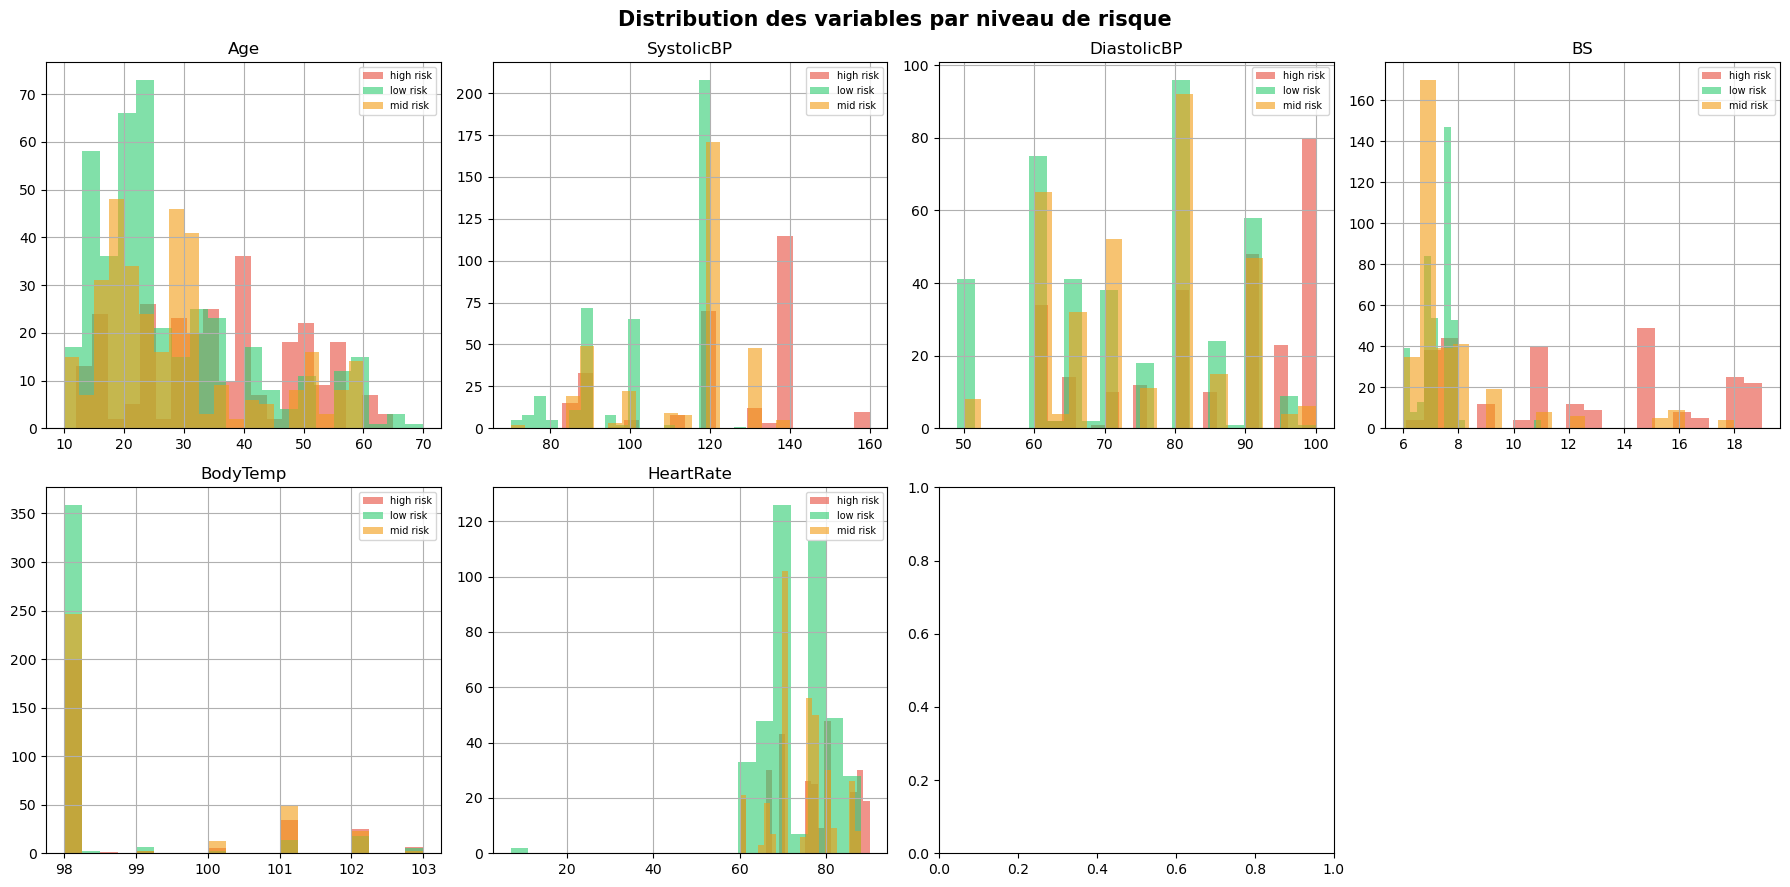

In [6]:
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
colors = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribution des variables par niveau de risque', fontsize=15, fontweight='bold')

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    for lvl, grp in df.groupby('RiskLevel'):
        grp[feat].hist(ax=ax, label=lvl, alpha=0.6, bins=20, color=colors[lvl])
    ax.set_title(feat)
    ax.legend(fontsize=7)
axes[1][3].axis('off')
plt.tight_layout()
plt.savefig('figures/01_distributions.png', dpi=150)
plt.show()

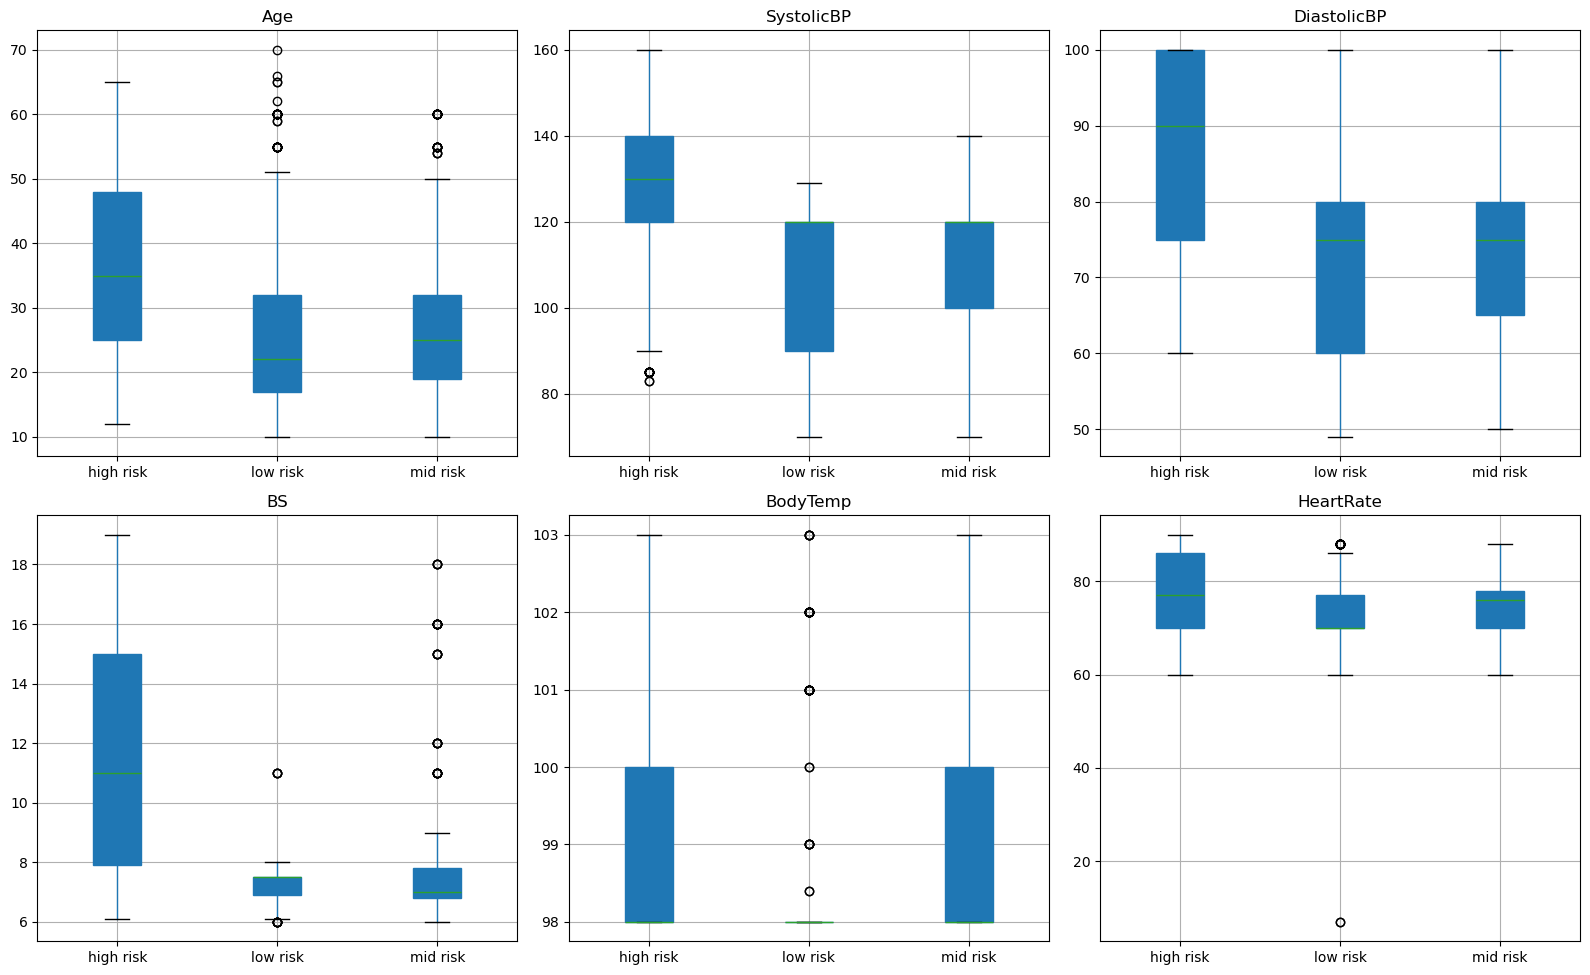

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots des variables par niveau de risque', fontsize=14, fontweight='bold')
for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    df.boxplot(column=feat, by='RiskLevel', ax=ax, patch_artist=True)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.savefig('figures/02_boxplots.png', dpi=150)
plt.show()

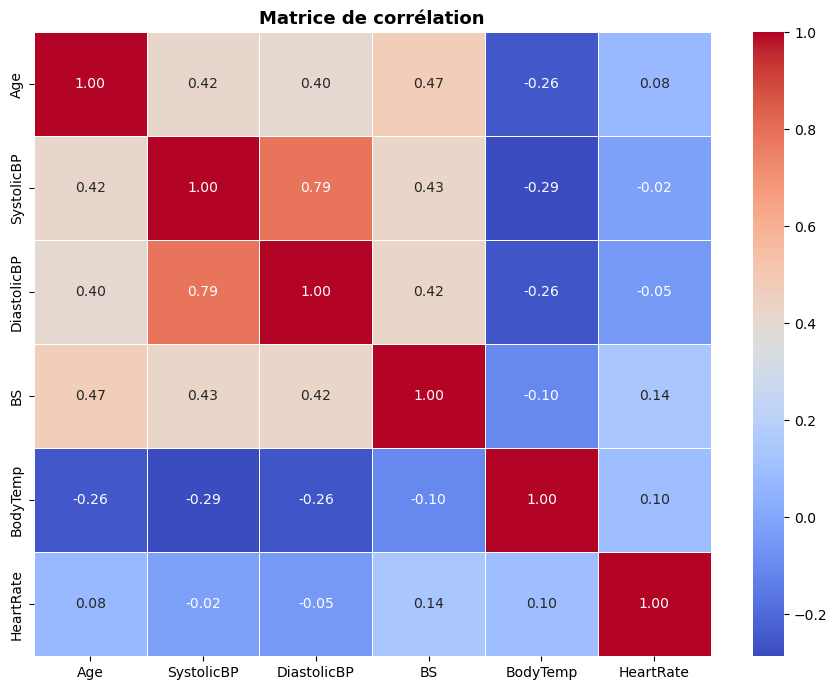

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_correlation.png', dpi=150)
plt.show()

## 3. Nettoyage & Correction des Aberrations

- **HeartRate < 30 bpm** → erreur décimale probable → correction × 10
- **BodyTemp hors [95, 105] °F** → valeur impossible → remplacée par la médiane


In [9]:
df_clean = df.copy()

# Correction HeartRate < 30 bpm → × 10
mask_hr = df_clean['HeartRate'] < 30
print(f'HeartRate < 30 bpm détectés : {mask_hr.sum()} → corrigés × 10')
df_clean.loc[mask_hr, 'HeartRate'] = df_clean.loc[mask_hr, 'HeartRate'] * 10

# BodyTemp hors [95, 105] → médiane
mask_bt = (df_clean['BodyTemp'] < 95) | (df_clean['BodyTemp'] > 105)
print(f'BodyTemp hors [95, 105] : {mask_bt.sum()} → remplacées par médiane')
df_clean.loc[mask_bt, 'BodyTemp'] = df_clean['BodyTemp'].median()

print('\nStatistiques après nettoyage :')
df_clean[['HeartRate', 'BodyTemp']].describe()

HeartRate < 30 bpm détectés : 2 → corrigés × 10
BodyTemp hors [95, 105] : 0 → remplacées par médiane

Statistiques après nettoyage :


,HeartRate,BodyTemp
count,1014.000000,1014.000000
mean,74.426036,98.665089
std,7.517006,1.371384
min,60.000000,98.000000
25%,70.000000,98.000000
50%,76.000000,98.000000
75%,80.000000,98.000000
max,90.000000,103.000000


## 4. Encodage & Feature Engineering

| Feature | Description | Justification clinique |
|---|---|---|
| `AgeBin_enc` | Tranche d'âge (0–3) | Segmentation démographique |
| `PulsePressure` | SystolicBP − DiastolicBP | Indicateur rigidité artérielle |
| `MAP` | (Syst + 2×Diast) / 3 | Pression artérielle moyenne standard |
| `HyperBP_flag` | 1 si ≥ 140/90 mmHg | Seuil HTA selon OMS |
| `HighBS_flag` | 1 si BS > 11 mmol/L | Seuil diabète selon OMS |


In [10]:
# Encodage de la cible (ordinal : low < mid < high)
df_clean['RiskLevel_enc'] = df_clean['RiskLevel'].map(
    {'low risk': 0, 'mid risk': 1, 'high risk': 2}
)
print('Encodage cible : low risk→0, mid risk→1, high risk→2')
print(df_clean['RiskLevel_enc'].value_counts().sort_index())

Encodage cible : low risk→0, mid risk→1, high risk→2
RiskLevel_enc
0    406
1    336
2    272
Name: count, dtype: int64


In [11]:
# Feature engineering
df_clean['AgeBin'] = pd.cut(
    df_clean['Age'], bins=[0, 20, 30, 40, 100],
    labels=['Adolescente', 'Jeune adulte', 'Adulte', 'Âgée']
)
df_clean['AgeBin_enc'] = df_clean['AgeBin'].cat.codes

df_clean['PulsePressure'] = df_clean['SystolicBP'] - df_clean['DiastolicBP']
df_clean['MAP']           = (df_clean['SystolicBP'] + 2 * df_clean['DiastolicBP']) / 3
df_clean['HyperBP_flag']  = ((df_clean['SystolicBP'] >= 140) | (df_clean['DiastolicBP'] >= 90)).astype(int)
df_clean['HighBS_flag']   = (df_clean['BS'] > 11).astype(int)

FEATURES = [
    'Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
    'AgeBin_enc', 'PulsePressure', 'MAP', 'HyperBP_flag', 'HighBS_flag'
]
X = df_clean[FEATURES].values
y = df_clean['RiskLevel_enc'].values

print(f'Shape X : {X.shape}  |  Shape y : {y.shape}')

Shape X : (1014, 11)  |  Shape y : (1014,)


## 5. Séparation Stratifiée + SMOTE

> **Ordre obligatoire :** Split → StandardScaler → SMOTE  
> Le scaler est fitté **uniquement** sur le train. Le SMOTE est appliqué **uniquement** sur le train normalisé.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train : {X_train.shape[0]} échantillons  |  Test : {X_test.shape[0]} échantillons')
print('Distribution train :', dict(zip(*np.unique(y_train, return_counts=True))))
print('Distribution test  :', dict(zip(*np.unique(y_test,  return_counts=True))))

# Standardisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_sc  = scaler.transform(X_test)         # transform uniquement sur test

# SMOTE
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)
print(f'\nAprès SMOTE : {X_train_sm.shape[0]} échantillons')
print('Distribution SMOTE :', dict(zip(*np.unique(y_train_sm, return_counts=True))))

Train : 811 échantillons  |  Test : 203 échantillons
Distribution train : {0: 325, 1: 269, 2: 217}
Distribution test  : {0: 81, 1: 67, 2: 55}

Après SMOTE : 975 échantillons
Distribution SMOTE : {0: 325, 1: 325, 2: 325}


## 6. Modélisation — Entraînement & Évaluation

In [13]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
CLASS_NAMES = ['low risk', 'mid risk', 'high risk']

MODELS = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=SEED),
        'param_grid': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'saga'],
            'penalty': ['l2'],
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=SEED),
        'param_grid': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy'],
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5],
            'max_features': ['sqrt', 'log2'],
        }
    },
    'SVM': {
        'estimator': SVC(probability=True, random_state=SEED),
        'param_grid': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear', 'poly'],
            'gamma': ['scale', 'auto'],
        }
    },
}
print('✔  Modèles définis.')

✔  Modèles définis.



────────────────────────────────────────────────────────────
  ► Logistic Regression
────────────────────────────────────────────────────────────
  CV Accuracy baseline : 0.6522 ± 0.0307
  Meilleurs hyperparamètres : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  Meilleur score CV (F1-weighted) : 0.6540

  ── Résultats sur le test set ──
  Accuracy  : 0.6552
  Precision : 0.6434
  Recall    : 0.6552
  F1-score  : 0.6474
  ROC-AUC   : 0.8202

  Rapport de classification :
              precision    recall  f1-score   support

    low risk       0.67      0.68      0.67        81
    mid risk       0.50      0.43      0.46        67
   high risk       0.78      0.89      0.83        55

    accuracy                           0.66       203
   macro avg       0.65      0.67      0.66       203
weighted avg       0.64      0.66      0.65       203



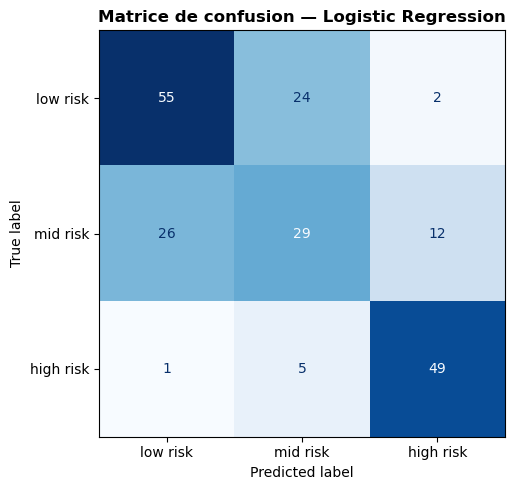


────────────────────────────────────────────────────────────
  ► Decision Tree
────────────────────────────────────────────────────────────
  CV Accuracy baseline : 0.8451 ± 0.0299
  Meilleurs hyperparamètres : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Meilleur score CV (F1-weighted) : 0.8444

  ── Résultats sur le test set ──
  Accuracy  : 0.8128
  Precision : 0.8175
  Recall    : 0.8128
  F1-score  : 0.8139
  ROC-AUC   : 0.9117

  Rapport de classification :
              precision    recall  f1-score   support

    low risk       0.85      0.78      0.81        81
    mid risk       0.72      0.79      0.75        67
   high risk       0.89      0.89      0.89        55

    accuracy                           0.81       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.81      0.81       203



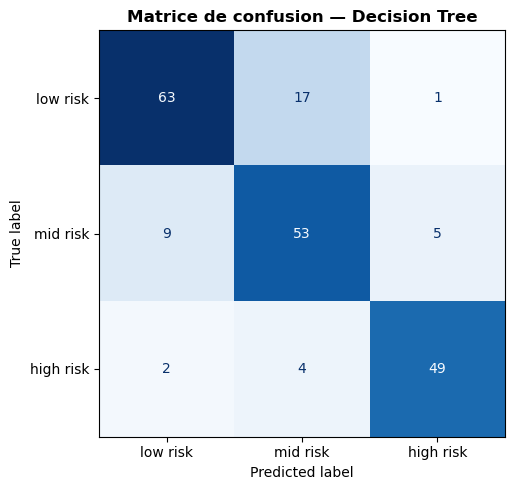


────────────────────────────────────────────────────────────
  ► Random Forest
────────────────────────────────────────────────────────────
  CV Accuracy baseline : 0.8564 ± 0.0375
  Meilleurs hyperparamètres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  Meilleur score CV (F1-weighted) : 0.8618

  ── Résultats sur le test set ──
  Accuracy  : 0.8473
  Precision : 0.8472
  Recall    : 0.8473
  F1-score  : 0.8463
  ROC-AUC   : 0.9512

  Rapport de classification :
              precision    recall  f1-score   support

    low risk       0.87      0.80      0.83        81
    mid risk       0.79      0.81      0.80        67
   high risk       0.88      0.96      0.92        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.85       203
weighted avg       0.85      0.85      0.85       203



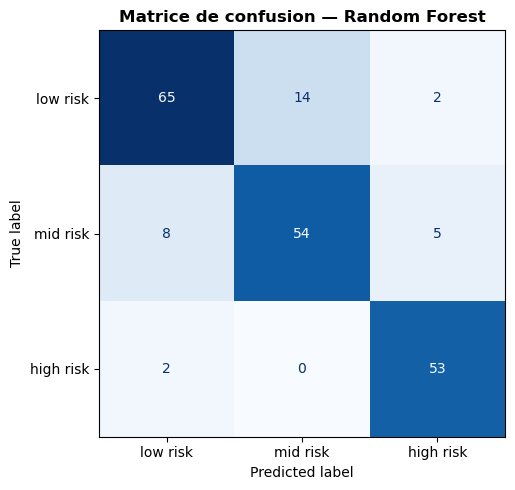


────────────────────────────────────────────────────────────
  ► SVM
────────────────────────────────────────────────────────────
  CV Accuracy baseline : 0.7015 ± 0.0471
  Meilleurs hyperparamètres : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
  Meilleur score CV (F1-weighted) : 0.7875

  ── Résultats sur le test set ──
  Accuracy  : 0.7685
  Precision : 0.7659
  Recall    : 0.7685
  F1-score  : 0.7666
  ROC-AUC   : 0.8871

  Rapport de classification :
              precision    recall  f1-score   support

    low risk       0.75      0.77      0.76        81
    mid risk       0.71      0.66      0.68        67
   high risk       0.86      0.91      0.88        55

    accuracy                           0.77       203
   macro avg       0.77      0.78      0.77       203
weighted avg       0.77      0.77      0.77       203



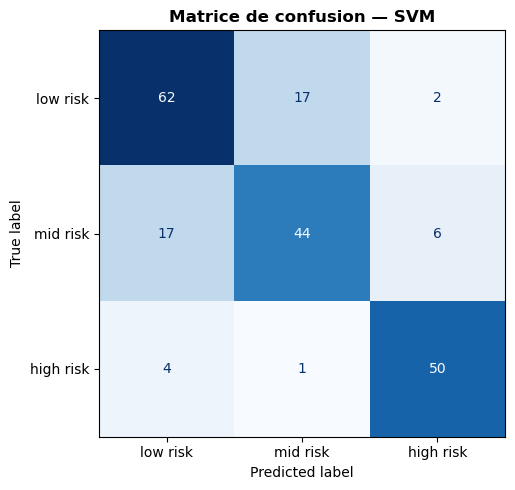

In [14]:
results = {}

for name, cfg in MODELS.items():
    print(f"\n{'─'*60}")
    print(f'  ► {name}')
    print(f"{'─'*60}")

    # Validation croisée baseline
    cv_scores = cross_val_score(
        cfg['estimator'], X_train_sm, y_train_sm,
        cv=cv, scoring='accuracy', n_jobs=-1
    )
    print(f'  CV Accuracy baseline : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # GridSearchCV
    gs = GridSearchCV(
        cfg['estimator'], cfg['param_grid'],
        cv=cv, scoring='f1_weighted',
        n_jobs=-1, verbose=0, refit=True
    )
    gs.fit(X_train_sm, y_train_sm)
    best_model = gs.best_estimator_
    print(f'  Meilleurs hyperparamètres : {gs.best_params_}')
    print(f'  Meilleur score CV (F1-weighted) : {gs.best_score_:.4f}')

    # Évaluation sur test set
    y_pred  = best_model.predict(X_test_sc)
    y_proba = best_model.predict_proba(X_test_sc)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    print(f'\n  ── Résultats sur le test set ──')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'\n  Rapport de classification :')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matrice de confusion — {name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"figures/cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

    results[name] = {
        'model': best_model, 'best_params': gs.best_params_,
        'cv_f1': gs.best_score_, 'accuracy': acc,
        'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba,
    }

## 7. Tableau Comparatif des Modèles

In [15]:
summary = pd.DataFrame({
    name: {
        'Accuracy':       r['accuracy'],
        'Precision':      r['precision'],
        'Recall':         r['recall'],
        'F1-score':       r['f1'],
        'ROC-AUC':        r['auc'],
        'CV F1-weighted': r['cv_f1'],
    }
    for name, r in results.items()
}).T.round(4)

display(summary)

best_model_name = summary['F1-score'].idxmax()
print(f'\n★  MODÈLE OPTIMAL : {best_model_name}  ★')
print(f'   F1-score = {summary.loc[best_model_name, "F1-score"]:.4f}')
print(f'   ROC-AUC  = {summary.loc[best_model_name, "ROC-AUC"]:.4f}')

,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV F1-weighted
Logistic Regression,0.6552,0.6434,0.6552,0.6474,0.8202,0.6540
Decision Tree,0.8128,0.8175,0.8128,0.8139,0.9117,0.8444
Random Forest,0.8473,0.8472,0.8473,0.8463,0.9512,0.8618
SVM,0.7685,0.7659,0.7685,0.7666,0.8871,0.7875



★  MODÈLE OPTIMAL : Random Forest  ★
   F1-score = 0.8463
   ROC-AUC  = 0.9512


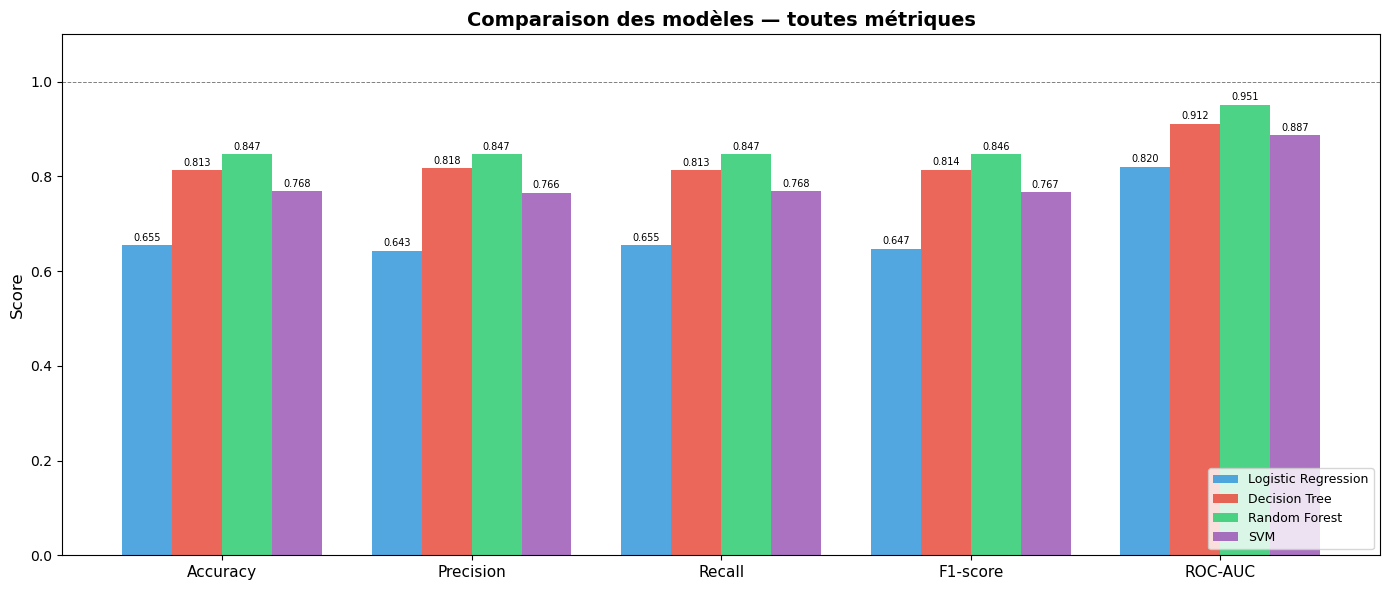

In [16]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
palette = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(summary.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=palette[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des modèles — toutes métriques', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig('figures/04_comparison.png', dpi=150)
plt.show()

## 8. Importance des Variables

Feature importances (Random Forest / DT) :
  BS                   : 0.2949
  MAP                  : 0.1253
  SystolicBP           : 0.1093
  Age                  : 0.1091
  HeartRate            : 0.0757
  PulsePressure        : 0.0741
  DiastolicBP          : 0.0633
  BodyTemp             : 0.0520
  HighBS_flag          : 0.0447
  AgeBin_enc           : 0.0378
  HyperBP_flag         : 0.0138


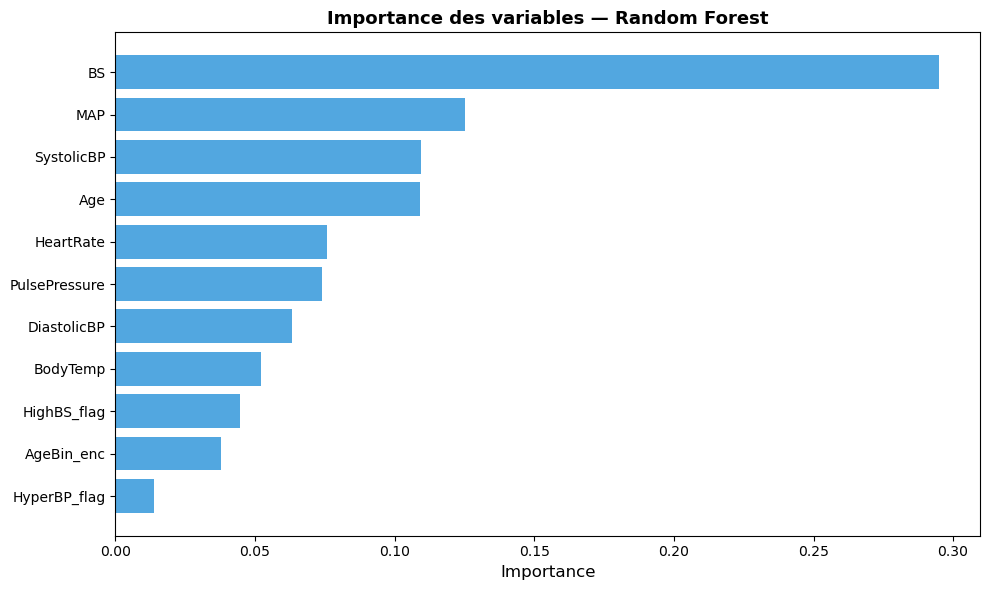

In [17]:
best = results[best_model_name]['model']

if hasattr(best, 'feature_importances_'):
    importances = best.feature_importances_
    idx = np.argsort(importances)[::-1]
    print('Feature importances (Random Forest / DT) :')
    for i in idx:
        print(f'  {FEATURES[i]:20s} : {importances[i]:.4f}')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEATURES[i] for i in idx[::-1]], importances[idx[::-1]], color='#3498db', alpha=0.85)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Importance des variables — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/05_feature_importance.png', dpi=150)
    plt.show()

elif hasattr(best, 'coef_'):
    coefs = np.abs(best.coef_).mean(axis=0)
    idx = np.argsort(coefs)[::-1]
    print('Importance via |coefficients| moyens (LR) :')
    for i in idx:
        print(f'  {FEATURES[i]:20s} : {coefs[i]:.4f}')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEATURES[i] for i in idx[::-1]], coefs[idx[::-1]], color='#e74c3c', alpha=0.85)
    ax.set_xlabel('|Coefficient| moyen', fontsize=12)
    ax.set_title(f'Importance des variables — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/05_feature_importance.png', dpi=150)
    plt.show()

else:
    rf_proxy = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
    rf_proxy.fit(X_train_sm, y_train_sm)
    importances = rf_proxy.feature_importances_
    idx = np.argsort(importances)[::-1]
    print('Importance des variables (proxy RF pour SVM) :')
    for i in idx:
        print(f'  {FEATURES[i]:20s} : {importances[i]:.4f}')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEATURES[i] for i in idx[::-1]], importances[idx[::-1]], color='#9b59b6', alpha=0.85)
    ax.set_xlabel('Importance (proxy RF)', fontsize=12)
    ax.set_title('Importance des variables — proxy RF (SVM optimal)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/05_feature_importance.png', dpi=150)
    plt.show()

## 9. Résumé Final

In [18]:
print('=' * 70)
print('RÉSUMÉ FINAL')
print('=' * 70)
print('Jeu de données : 1 014 observations, 6 features originales + 5 engineered')
print('Cible : 3 classes — Low Risk (0), Mid Risk (1), High Risk (2)')
print('SMOTE appliqué pour équilibrer les classes d\'entraînement')
print('Validation croisée stratifiée 10 folds appliquée à tous les modèles')
print('\nTableau final :')
display(summary)
print(f'\n★  MODÈLE OPTIMAL : {best_model_name}')
print(f'   → Meilleurs hyperparamètres : {results[best_model_name]["best_params"]}')
print(f'   → F1-score test : {results[best_model_name]["f1"]:.4f}')
print(f'   → ROC-AUC test  : {results[best_model_name]["auc"]:.4f}')
print('=' * 70)
print('FIN DU PIPELINE')
print('=' * 70)

RÉSUMÉ FINAL
Jeu de données : 1 014 observations, 6 features originales + 5 engineered
Cible : 3 classes — Low Risk (0), Mid Risk (1), High Risk (2)
SMOTE appliqué pour équilibrer les classes d'entraînement
Validation croisée stratifiée 10 folds appliquée à tous les modèles

Tableau final :


,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV F1-weighted
Logistic Regression,0.6552,0.6434,0.6552,0.6474,0.8202,0.6540
Decision Tree,0.8128,0.8175,0.8128,0.8139,0.9117,0.8444
Random Forest,0.8473,0.8472,0.8473,0.8463,0.9512,0.8618
SVM,0.7685,0.7659,0.7685,0.7666,0.8871,0.7875



★  MODÈLE OPTIMAL : Random Forest
   → Meilleurs hyperparamètres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   → F1-score test : 0.8463
   → ROC-AUC test  : 0.9512
FIN DU PIPELINE
